
# Transaction Categorization Model Comparison

This notebook compares different ML and hybrid models for classifying transactions into categories.

It is designed for short transaction text classification, where strong candidates are typically:
- Word TF-IDF + LinearSVC
- Calibrated LinearSVC
- Character TF-IDF + LinearSVC
- Word + Character TF-IDF + LinearSVC
- Rule-based + ML fallback hybrid

Key notes:
- Logistic Regression is a strong baseline and provides probabilities.
- LinearSVC is often very strong for sparse TF-IDF text classification.
- Calibrated LinearSVC adds confidence-like probabilities for review/auto-accept pipelines.
- Character n-grams help messy bank descriptions, OCR-like text, masked IBANs, and spelling variation.
- Random Forest is included for comparison but may underperform on very high-dimensional sparse TF-IDF.
- Rule-based logic is useful for fixed banking patterns (ATM, RAAST, VISA POS, KFC, CHEEZIOUS, APPLE, service charges).

Safety constraints for this experiment:
- Do not overwrite production model: `ml/models/categorizer.pkl`.
- Save only experiment artifacts.
- Use `random_state=42` consistently.


In [1]:

import os
import re
import sys
import json
import subprocess
import importlib.util
from pathlib import Path
from datetime import datetime

RANDOM_STATE = 42

REQUIRED_MODULES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "joblib": "joblib",
    "nbformat": "nbformat",
    "ipykernel": "ipykernel",
}

OPTIONAL_MODULES = {
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
    "imbalanced-learn": "imblearn",
}


def _missing_packages(module_map):
    missing = []
    for package_name, module_name in module_map.items():
        if importlib.util.find_spec(module_name) is None:
            missing.append(package_name)
    return missing


def _pip_install(packages, optional=False):
    if not packages:
        return True
    label = "optional" if optional else "required"
    print(f"Installing missing {label} packages: {packages}")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])
        return True
    except Exception as exc:
        print(f"WARNING: Could not install {label} packages {packages}. Error: {exc}")
        return False


missing_required = _missing_packages(REQUIRED_MODULES)
if missing_required:
    _pip_install(
        ["pandas", "numpy", "matplotlib", "scikit-learn", "joblib", "nbformat", "ipykernel"],
        optional=False,
    )

missing_optional = _missing_packages(OPTIONAL_MODULES)
if missing_optional:
    _pip_install(["xgboost", "lightgbm", "catboost", "imbalanced-learn"], optional=True)

# Core imports (must be available)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer

import joblib

np.random.seed(RANDOM_STATE)

# Optional imports (do not fail notebook if unavailable)
OPTIONAL_AVAILABILITY = {}
for package_name, module_name in OPTIONAL_MODULES.items():
    OPTIONAL_AVAILABILITY[package_name] = importlib.util.find_spec(module_name) is not None

print("Active Python:", sys.executable)
print("Required packages missing before auto-install:", missing_required)
print("Optional packages missing before auto-install:", missing_optional)
print("Optional availability after checks:", OPTIONAL_AVAILABILITY)


Active Python: D:\fyp\ml\.venv\Scripts\python.exe
Required packages missing before auto-install: []
Optional packages missing before auto-install: []
Optional availability after checks: {'xgboost': True, 'lightgbm': True, 'catboost': True, 'imbalanced-learn': True}


In [ ]:
# Dataset paths + project root resolution (works from project root, ml/, and nested notebook dirs)

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents]

    for candidate in search_roots:
        if (candidate / "ml" / "data").exists():
            return candidate
        if candidate.name.lower() == "ml" and (candidate / "data").exists():
            return candidate.parent

    raise RuntimeError(
        f"Could not resolve project root from {cwd}. Run from project root or ml/ folder."
    )


PROJECT_ROOT = resolve_project_root()
ML_DIR = PROJECT_ROOT / "ml"
DATA_DIR = ML_DIR / "data"
MODELS_DIR = ML_DIR / "models"
NOTEBOOKS_DIR = ML_DIR / "notebooks"

KNOWN_DATASETS = [
    "pakistani.csv",
    "transactions.csv",
    "business.csv",
    "askari.csv",
    "corrections_feedback.csv",
    "data.csv",
]

resolved_dataset_paths = list(DATA_DIR.glob("*.csv"))
for filename in KNOWN_DATASETS:
    candidate = DATA_DIR / filename
    if candidate.exists() and candidate not in resolved_dataset_paths:
        resolved_dataset_paths.append(candidate)
    if not candidate.exists():
        print(f"WARNING: Known dataset missing: {filename}")

dataset_paths = sorted({path.resolve() for path in resolved_dataset_paths}, key=lambda p: p.name.lower())

expected_ml_venv_python = ML_DIR / ".venv" / "Scripts" / "python.exe"
if expected_ml_venv_python.exists() and Path(sys.executable).resolve() != expected_ml_venv_python.resolve():
    print("WARNING: Active Python is not ml/.venv interpreter.")
    print("Expected:", expected_ml_venv_python)

print("Project root:", PROJECT_ROOT)
print("ML dir:", ML_DIR)
print("Data dir:", DATA_DIR)
print("Models dir:", MODELS_DIR)
print("Found dataset files:")
for path in dataset_paths:
    print(" -", path.name)

Project root: D:\fyp
ML dir: D:\fyp\ml
Data dir: D:\fyp\ml\data
Models dir: D:\fyp\ml\models
Found dataset files:
 - askari.csv
 - business.csv
 - corrections_feedback.csv
 - data.csv
 - pakistani.csv
 - transactions.csv


In [3]:

# Helper functions

NOISY_IDENTIFIER_RE = re.compile(
    r"\b(?:txn|trx|tx|id|ref|reference|rrn|trace|auth)\s*[:#-]?\s*[a-z0-9-]{4,}\b",
    re.IGNORECASE,
)
ACCOUNT_FRAGMENT_RE = re.compile(
    r"\b(?:a/?c|account|iban|acc|cnic|phone|mobile)\s*[:#-]?\s*[0-9*x-]{4,}\b",
    re.IGNORECASE,
)
LONG_NUMBER_RE = re.compile(r"\b\d{6,}\b")

CATEGORY_EXACT_MAP = {
    "Car Maintenance": "Transport",
    "Charity & Donations": "Charity",
    "Coffee & Snacks": "Food & Dining",
    "Education / Tuition": "Education",
    "Electricity / Water / Gas": "Bills",
    "Entertainment & Recreation": "Entertainment",
    "Entertainment (Movies / Games / Events)": "Entertainment",
    "Fees": "Fees & Charges",
    "Financial Services": "Fees & Charges",
    "Fuel / Gas": "Transport",
    "Gifts & Celebrations": "Shopping",
    "Government & Legal": "Government/Legal",
    "Healthcare & Medical": "Healthcare",
    "Home Supplies / Household Items": "Shopping",
    "Housing / Rent": "Bills",
    "Insurance": "Bills",
    "Medical / Pharmacy": "Healthcare",
    "Mobile & Internet": "Bills",
    "Public Transport": "Transport",
    "Restaurants / Eating Out": "Food & Dining",
    "Ride Sharing / Taxi": "Transport",
    "Savings / Investments": "Transfers",
    "Shopping & Retail": "Shopping",
    "Shopping (Clothes / Electronics)": "Shopping",
    "Subscriptions (Streaming / Apps)": "Subscriptions",
    "Transportation": "Transport",
    "Travel (Flights / Hotels)": "Transport",
    "Utilities & Services": "Bills",
    "Shopping/Groceries": "Groceries",
    "Fuel": "Transport",
}

BUSINESS_PREFIX_MAP = {
    "Retail": "Shopping",
    "Dining and Drinking": "Food & Dining",
    "Business and Professional Services": "Fees & Charges",
    "Community and Government": "Government/Legal",
    "Travel and Transportation": "Transport",
    "Health and Medicine": "Healthcare",
    "Sports and Recreation": "Entertainment",
    "Arts and Entertainment": "Entertainment",
    "Event": "Entertainment",
    "Landmarks and Outdoors": "Other",
}


def clean_text(value: str) -> str:
    text = str(value or "").strip().lower()
    if not text:
        return ""

    text = NOISY_IDENTIFIER_RE.sub(" ", text)
    text = ACCOUNT_FRAGMENT_RE.sub(" ", text)
    text = LONG_NUMBER_RE.sub(" ", text)
    text = re.sub(r"[^a-z0-9/&+\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_category(value: str) -> str:
    raw = str(value or "").strip()
    if not raw:
        return ""

    if raw in CATEGORY_EXACT_MAP:
        return CATEGORY_EXACT_MAP[raw]

    if ">" in raw:
        prefix = raw.split(">", 1)[0].strip()
        if prefix in BUSINESS_PREFIX_MAP:
            return BUSINESS_PREFIX_MAP[prefix]

    lowered = raw.lower()
    if "fee" in lowered or "charge" in lowered:
        return "Fees & Charges"
    if "withdraw" in lowered or "atm" in lowered:
        return "Cash Withdrawal"
    if "grocery" in lowered:
        return "Groceries"
    if "restaurant" in lowered or "food" in lowered or "dining" in lowered:
        return "Food & Dining"
    if "subscription" in lowered or "itunes" in lowered or "netflix" in lowered:
        return "Subscriptions"
    if "transport" in lowered or "fuel" in lowered or "careem" in lowered or "uber" in lowered:
        return "Transport"
    if "transfer" in lowered or "ibft" in lowered or "raast" in lowered:
        return "Transfers"
    if "income" in lowered or "salary" in lowered:
        return "Income"
    if "education" in lowered or "university" in lowered:
        return "Education"

    return raw


def detect_source_bank_if_missing(row: pd.Series) -> str:
    current = str(row.get("source_bank", "") or "").strip()
    if current:
        return current

    text = " ".join(
        [
            str(row.get("description", "") or ""),
            str(row.get("merchant", "") or ""),
            str(row.get("channel", "") or ""),
        ]
    ).lower()

    if "askari" in text:
        return "Askari Bank"
    if "easypaisa" in text or "telenor" in text:
        return "Easypaisa"
    if "sadapay" in text:
        return "SadaPay"
    if "ubl" in text:
        return "UBL"
    if "hbl" in text:
        return "HBL"
    if "meezan" in text:
        return "Meezan"
    if "alfa" in text or "abl" in text:
        return "Allied Bank"
    if "raast" in text:
        return "RAAST"

    return "unknown"


def build_text_features(row: pd.Series) -> str:
    parts = [
        clean_text(row.get("description", "")),
        clean_text(row.get("merchant", "")),
        clean_text(row.get("type", "")),
        clean_text(row.get("channel", "")),
        clean_text(row.get("source_bank", "")),
    ]
    merged = " ".join(part for part in parts if part).strip()
    return merged if merged else "unknown transaction"


def load_transaction_dataset(file_path: Path):
    file_path = Path(file_path)

    if not file_path.exists():
        return None, {
            "file": file_path.name,
            "status": "skipped",
            "reason": "file_missing",
        }

    try:
        try:
            frame = pd.read_csv(file_path, encoding="utf-8")
        except UnicodeDecodeError:
            frame = pd.read_csv(file_path, encoding="latin-1")
    except Exception as exc:
        return None, {
            "file": file_path.name,
            "status": "skipped",
            "reason": f"read_error: {exc}",
        }

    original_rows = len(frame)
    frame.columns = [str(column).strip().lower() for column in frame.columns]

    if "category" not in frame.columns:
        return None, {
            "file": file_path.name,
            "status": "skipped",
            "reason": "missing_category_column",
            "rows": int(original_rows),
        }

    keep_columns = ["date", "description", "merchant", "amount", "type", "channel", "source_bank", "category"]
    for column in keep_columns:
        if column not in frame.columns:
            frame[column] = "" if column != "amount" else 0

    work = frame[keep_columns].copy()

    for column in ["date", "description", "merchant", "type", "channel", "source_bank", "category"]:
        work[column] = work[column].fillna("").astype(str).str.strip()

    work["amount"] = pd.to_numeric(work["amount"], errors="coerce").fillna(0.0)
    work["category"] = work["category"].apply(normalize_category).astype(str).str.strip()
    work = work[work["category"] != ""].copy()

    if work.empty:
        return None, {
            "file": file_path.name,
            "status": "skipped",
            "reason": "no_rows_after_category_filter",
            "rows": int(original_rows),
        }

    work["source_bank"] = work.apply(detect_source_bank_if_missing, axis=1)
    work["text_features"] = work.apply(build_text_features, axis=1)
    work["dataset_source"] = file_path.name

    report = {
        "file": file_path.name,
        "status": "loaded",
        "rows_before": int(original_rows),
        "rows_after": int(len(work)),
        "category_count": int(work["category"].nunique()),
        "columns": list(work.columns),
    }

    return work, report


def print_dataset_report(report: dict, frame: pd.DataFrame) -> None:
    print("=" * 80)
    print(f"Dataset: {report['file']}")
    print(f"Rows before/after: {report.get('rows_before', 0)} -> {report.get('rows_after', 0)}")
    print(f"Columns: {list(frame.columns)}")
    print(f"Unique categories: {report.get('category_count', 0)}")
    print("Top categories:")
    print(frame["category"].value_counts().head(15))
    print("=" * 80)


In [4]:

# Load all usable datasets

loaded_frames = []
loaded_reports = []
skipped_datasets = []

for path in dataset_paths:
    frame, report = load_transaction_dataset(path)
    if frame is None:
        skipped_datasets.append(report)
        print(f"WARNING: Skipping {report.get('file')} -> {report.get('reason')}")
        continue

    loaded_frames.append(frame)
    loaded_reports.append(report)
    print_dataset_report(report, frame)

if not loaded_frames:
    raise RuntimeError("No usable datasets with a valid category column were loaded.")

combined_df = pd.concat(loaded_frames, ignore_index=True)

print("\nSummary")
print("-" * 80)
print(f"Datasets loaded: {len(loaded_frames)}")
print(f"Datasets skipped: {len(skipped_datasets)}")
print(f"Total rows (combined): {len(combined_df)}")
print(f"Combined columns: {list(combined_df.columns)}")
print("\nCombined category distribution (top 30):")
print(combined_df["category"].value_counts().head(30))

if skipped_datasets:
    print("\nSkipped datasets detail:")
    for skipped in skipped_datasets:
        print(f"- {skipped.get('file')}: {skipped.get('reason')}")


Dataset: askari.csv
Rows before/after: 680 -> 680
Columns: ['date', 'description', 'merchant', 'amount', 'type', 'channel', 'source_bank', 'category', 'text_features', 'dataset_source']
Unique categories: 15
Top categories:
category
Transfers             350
Income                166
Cash Withdrawal        39
Fees & Charges         38
Food & Dining          38
Groceries              14
Transport              12
Education               6
Shopping                5
Refund/Reversal         4
Bank Adjustment         2
Entertainment           2
Rent/Hostel             2
Subscriptions           1
Healthcare/Fitness      1
Name: count, dtype: int64


Dataset: business.csv
Rows before/after: 17471 -> 17471
Columns: ['date', 'description', 'merchant', 'amount', 'type', 'channel', 'source_bank', 'category', 'text_features', 'dataset_source']
Unique categories: 15
Top categories:
category
Shopping                              4338
Fees & Charges                        4073
Food & Dining                         3964
Government/Legal                      1584
Transport                              993
Healthcare                             828
Other                                  667
Entertainment                          660
Retail                                 100
Arts and Entertainment                  93
Business and Professional Services      57
Health and Medicine                     53
Community and Government                31
Sports and Recreation                   29
Landmarks and Outdoors                   1
Name: count, dtype: int64


Dataset: pakistani.csv
Rows before/after: 7000 -> 7000
Columns: ['date', 'description', 'merchant', 'amount', 'type', 'channel', 'source_bank', 'category', 'text_features', 'dataset_source']
Unique categories: 15
Top categories:
category
Transfers           1067
Transport            893
Bills                810
Shopping             702
Food & Dining        594
Entertainment        494
Healthcare           494
Fees & Charges       395
Income               394
Government/Legal     393
Charity              393
Subscriptions        137
Education            100
Groceries            100
Cash Withdrawal       34
Name: count, dtype: int64


Dataset: transactions.csv
Rows before/after: 7000 -> 7000
Columns: ['date', 'description', 'merchant', 'amount', 'type', 'channel', 'source_bank', 'category', 'text_features', 'dataset_source']
Unique categories: 15
Top categories:
category
Transfers           1067
Transport            893
Bills                810
Shopping             702
Food & Dining        594
Healthcare           494
Entertainment        494
Fees & Charges       395
Income               394
Charity              393
Government/Legal     393
Subscriptions        137
Education            100
Groceries            100
Cash Withdrawal       34
Name: count, dtype: int64

Summary
--------------------------------------------------------------------------------
Datasets loaded: 4
Datasets skipped: 2
Total rows (combined): 32151
Combined columns: ['date', 'description', 'merchant', 'amount', 'type', 'channel', 'source_bank', 'category', 'text_features', 'dataset_source']

Combined category distribution (top 30):
category
Shop

In [5]:

# Clean features and labels

model_df = combined_df.copy()

model_df["text_features"] = model_df["text_features"].fillna("").astype(str).str.strip()
model_df["category"] = model_df["category"].fillna("").astype(str).str.strip().apply(normalize_category)

# Remove empty text/category rows
model_df = model_df[(model_df["text_features"] != "") & (model_df["category"] != "")].copy()

# Handle extremely rare categories
min_samples = 2
counts_before = model_df["category"].value_counts()
rare_categories = counts_before[counts_before < min_samples].index.tolist()
if rare_categories:
    model_df.loc[model_df["category"].isin(rare_categories), "category"] = "Other"

# One extra safety pass
counts_after = model_df["category"].value_counts()
still_rare = counts_after[counts_after < min_samples].index.tolist()
if still_rare:
    model_df = model_df[~model_df["category"].isin(still_rare)].copy()

print(f"Final dataset rows: {len(model_df)}")
print(f"Final category count: {model_df['category'].nunique()}")
print("Final category distribution (top 40):")
print(model_df["category"].value_counts().head(40))


Final dataset rows: 32151
Final category count: 25
Final category distribution (top 40):
category
Shopping                              5747
Food & Dining                         5190
Fees & Charges                        4901
Transport                             2791
Transfers                             2484
Government/Legal                      2370
Healthcare                            1816
Entertainment                         1650
Bills                                 1620
Income                                 954
Charity                                786
Other                                  669
Subscriptions                          275
Groceries                              214
Education                              206
Cash Withdrawal                        107
Retail                                 100
Arts and Entertainment                  93
Business and Professional Services      57
Health and Medicine                     53
Community and Government                31

In [6]:

# Train/test split

required_feature_cols = ["text_features", "amount", "type", "channel", "source_bank", "description", "merchant", "date", "dataset_source"]
for column in required_feature_cols:
    if column not in model_df.columns:
        model_df[column] = "" if column != "amount" else 0.0

X = model_df[required_feature_cols].copy()
y = model_df["category"].copy()

stratify_used = True
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )
except Exception as exc:
    stratify_used = False
    print(f"WARNING: Stratified split failed ({exc}). Falling back to non-stratified split.")
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=None,
    )

# Reset indices for easier downstream row-wise operations
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train_text = X_train["text_features"].astype(str)
X_test_text = X_test["text_features"].astype(str)

structured_cols = ["text_features", "amount", "type", "channel", "source_bank"]
X_train_structured = X_train[structured_cols].copy()
X_test_structured = X_test[structured_cols].copy()

for col in ["type", "channel", "source_bank"]:
    X_train_structured[col] = X_train_structured[col].fillna("").astype(str)
    X_test_structured[col] = X_test_structured[col].fillna("").astype(str)

X_train_structured["amount"] = pd.to_numeric(X_train_structured["amount"], errors="coerce").fillna(0.0)
X_test_structured["amount"] = pd.to_numeric(X_test_structured["amount"], errors="coerce").fillna(0.0)

print("Train rows:", len(X_train), "| Test rows:", len(X_test))
print("Stratify used:", stratify_used)
print("Train category distribution (top 20):")
print(y_train.value_counts().head(20))


Train rows: 25720 | Test rows: 6431
Stratify used: True
Train category distribution (top 20):
category
Shopping                              4597
Food & Dining                         4152
Fees & Charges                        3921
Transport                             2233
Transfers                             1987
Government/Legal                      1896
Healthcare                            1453
Entertainment                         1320
Bills                                 1296
Income                                 763
Charity                                629
Other                                  535
Subscriptions                          220
Groceries                              171
Education                              165
Cash Withdrawal                         85
Retail                                  80
Arts and Entertainment                  74
Business and Professional Services      46
Health and Medicine                     42
Name: count, dtype: int64


In [7]:

# Evaluation helpers

results = []
trained_models = {}
predictions_store = {}
model_input_kind = {}
failed_models = {}


def evaluate_predictions(name, y_true, y_pred, trained_model=None, input_kind="text"):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    metrics_row = {
        "model_name": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

    results.append(metrics_row)
    predictions_store[name] = y_pred.to_numpy()
    model_input_kind[name] = input_kind
    if trained_model is not None:
        trained_models[name] = trained_model

    print(f"\n=== {name} ===")
    print(
        f"accuracy={metrics_row['accuracy']:.4f} | "
        f"macro_f1={metrics_row['macro_f1']:.4f} | "
        f"weighted_f1={metrics_row['weighted_f1']:.4f} | "
        f"precision_macro={metrics_row['precision_macro']:.4f} | "
        f"recall_macro={metrics_row['recall_macro']:.4f}"
    )
    print(classification_report(y_true, y_pred, zero_division=0))

    return metrics_row


def evaluate_model(name, model, X_train_data, X_test_data, y_train_data, y_test_data, input_kind="text"):
    try:
        fitted_model = model.fit(X_train_data, y_train_data)
        y_pred = fitted_model.predict(X_test_data)
        metrics_row = evaluate_predictions(
            name,
            y_test_data,
            y_pred,
            trained_model=fitted_model,
            input_kind=input_kind,
        )
        return fitted_model, metrics_row
    except Exception as exc:
        failed_models[name] = str(exc)
        print(f"WARNING: {name} failed and was skipped. Error: {exc}")
        return None, None


def predict_with_model(model_name, model_obj, frame: pd.DataFrame):
    kind = model_input_kind.get(model_name, "text")

    if kind == "structured":
        data = frame[["text_features", "amount", "type", "channel", "source_bank"]].copy()
        for col in ["type", "channel", "source_bank"]:
            data[col] = data[col].fillna("").astype(str)
        data["amount"] = pd.to_numeric(data["amount"], errors="coerce").fillna(0.0)
        return model_obj.predict(data)

    if kind == "text_encoded":
        encoded_model = model_obj["pipeline"]
        label_encoder = model_obj["label_encoder"]
        encoded_pred = encoded_model.predict(frame["text_features"].astype(str))
        encoded_pred = np.asarray(encoded_pred).reshape(-1).astype(int)
        return label_encoder.inverse_transform(encoded_pred)

    # Default text mode
    return model_obj.predict(frame["text_features"].astype(str))


In [8]:

# Model 1: TF-IDF + Logistic Regression

model_name = "TF-IDF + Logistic Regression"
model_1 = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=False,
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

_ = evaluate_model(model_name, model_1, X_train_text, X_test_text, y_train, y_test, input_kind="text")



=== TF-IDF + Logistic Regression ===
accuracy=0.8817 | macro_f1=0.7228 | weighted_f1=0.8886 | precision_macro=0.7029 | recall_macro=0.7789


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.31      0.68      0.43        19
                             Bills       0.99      1.00      1.00       324
Business and Professional Services       0.04      0.09      0.06        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       1.00      1.00      1.00       157
          Community and Government       0.10      0.17      0.12         6
                         Education       1.00      1.00      1.00        41
                     Entertainment       0.91      0.84      0.87       330
                    Fees & Charges       0.85      0.87      0.86       980
                     Food & Dining       0.89      0.86      0.88      1038
                  Government/Legal       0.92      0.89      0.90       474
                         Groceries       0.40      1.00      0.57        43
           

In [9]:

# Model 2: TF-IDF + LinearSVC

model_name = "TF-IDF + LinearSVC"
model_2 = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        (
            "clf",
            LinearSVC(class_weight="balanced"),
        ),
    ]
)

_ = evaluate_model(model_name, model_2, X_train_text, X_test_text, y_train, y_test, input_kind="text")


D:\fyp\ml\.venv\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


D:\fyp\ml\.venv\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== TF-IDF + LinearSVC ===
accuracy=0.9201 | macro_f1=0.7351 | weighted_f1=0.9211 | precision_macro=0.7287 | recall_macro=0.7438


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.30      0.42      0.35        19
                             Bills       1.00      1.00      1.00       324
Business and Professional Services       0.07      0.09      0.08        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       1.00      1.00      1.00       157
          Community and Government       0.14      0.17      0.15         6
                         Education       1.00      1.00      1.00        41
                     Entertainment       0.90      0.91      0.91       330
                    Fees & Charges       0.90      0.89      0.89       980
                     Food & Dining       0.94      0.94      0.94      1038
                  Government/Legal       0.93      0.92      0.93       474
                         Groceries       0.61      0.79      0.69        43
           

In [10]:
# Model 3: TF-IDF + Calibrated LinearSVC
# This is close to the current project style (LinearSVC-centric text classifier),
# with calibration added to produce probability-like confidence scores.

from IPython.display import display, Markdown

display(Markdown('''
### Model 3 note
This model is close to your current TF-IDF/LinearSVC direction, but adds calibration so scores are more usable as confidence for review/auto-accept style workflows.
'''))

# CalibratedClassifierCV requires enough samples per class for CV folds.
# Use adaptive CV to avoid hard failure when minority classes are very small.
min_class_samples = int(y_train.value_counts().min())
adaptive_cv = max(2, min(3, min_class_samples))
print(f"Using adaptive calibration cv={adaptive_cv} (min class samples in train={min_class_samples})")

model_name = "TF-IDF + Calibrated LinearSVC"
model_3 = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        (
            "clf",
            CalibratedClassifierCV(
                LinearSVC(class_weight="balanced"),
                cv=adaptive_cv,
            ),
        ),
    ]
)

_ = evaluate_model(model_name, model_3, X_train_text, X_test_text, y_train, y_test, input_kind="text")


### Model 3 note
This model is close to your current TF-IDF/LinearSVC direction, but adds calibration so scores are more usable as confidence for review/auto-accept style workflows.


Using adaptive calibration cv=2 (min class samples in train=2)


D:\fyp\ml\.venv\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


D:\fyp\ml\.venv\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(



=== TF-IDF + Calibrated LinearSVC ===
accuracy=0.9258 | macro_f1=0.7004 | weighted_f1=0.9211 | precision_macro=0.7104 | recall_macro=0.6943


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.22      0.11      0.14        19
                             Bills       1.00      1.00      1.00       324
Business and Professional Services       0.00      0.00      0.00        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       1.00      1.00      1.00       157
          Community and Government       0.00      0.00      0.00         6
                         Education       1.00      1.00      1.00        41
                     Entertainment       0.91      0.93      0.92       330
                    Fees & Charges       0.87      0.91      0.89       980
                     Food & Dining       0.92      0.96      0.94      1038
                  Government/Legal       0.92      0.92      0.92       474
                         Groceries       0.81      0.60      0.69        43
           

In [11]:

# Model 4: Character n-gram TF-IDF + LinearSVC

from IPython.display import display, Markdown

display(Markdown('''
### Why character n-grams?
Character n-grams often improve robustness on messy bank descriptions, spelling variations, masked IBAN fragments, merchant aliases, and OCR-like statement text.
'''))

model_name = "Character TF-IDF + LinearSVC"
model_4 = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                max_features=70000,
                min_df=2,
            ),
        ),
        (
            "clf",
            LinearSVC(class_weight="balanced"),
        ),
    ]
)

_ = evaluate_model(model_name, model_4, X_train_text, X_test_text, y_train, y_test, input_kind="text")



### Why character n-grams?
Character n-grams often improve robustness on messy bank descriptions, spelling variations, masked IBAN fragments, merchant aliases, and OCR-like statement text.


D:\fyp\ml\.venv\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


D:\fyp\ml\.venv\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== Character TF-IDF + LinearSVC ===
accuracy=0.9104 | macro_f1=0.7350 | weighted_f1=0.9140 | precision_macro=0.7231 | recall_macro=0.7604


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.22      0.42      0.29        19
                             Bills       1.00      1.00      1.00       324
Business and Professional Services       0.00      0.00      0.00        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       0.99      1.00      1.00       157
          Community and Government       0.25      0.17      0.20         6
                         Education       1.00      1.00      1.00        41
                     Entertainment       0.90      0.90      0.90       330
                    Fees & Charges       0.89      0.87      0.88       980
                     Food & Dining       0.94      0.92      0.93      1038
                  Government/Legal       0.92      0.92      0.92       474
                         Groceries       0.49      0.91      0.63        43
           

In [12]:

# Model 5: Word + Character Hybrid TF-IDF + LinearSVC

model_name = "Word + Character TF-IDF + LinearSVC"
model_5 = Pipeline(
    steps=[
        (
            "features",
            FeatureUnion(
                transformer_list=[
                    (
                        "word_tfidf",
                        TfidfVectorizer(
                            max_features=50000,
                            ngram_range=(1, 2),
                            min_df=2,
                        ),
                    ),
                    (
                        "char_tfidf",
                        TfidfVectorizer(
                            analyzer="char_wb",
                            ngram_range=(3, 5),
                            max_features=70000,
                            min_df=2,
                        ),
                    ),
                ]
            ),
        ),
        (
            "clf",
            LinearSVC(class_weight="balanced"),
        ),
    ]
)

_ = evaluate_model(model_name, model_5, X_train_text, X_test_text, y_train, y_test, input_kind="text")


D:\fyp\ml\.venv\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


D:\fyp\ml\.venv\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== Word + Character TF-IDF + LinearSVC ===
accuracy=0.9249 | macro_f1=0.7270 | weighted_f1=0.9252 | precision_macro=0.7238 | recall_macro=0.7322


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.20      0.26      0.23        19
                             Bills       1.00      1.00      1.00       324
Business and Professional Services       0.08      0.09      0.08        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       1.00      1.00      1.00       157
          Community and Government       0.20      0.17      0.18         6
                         Education       1.00      1.00      1.00        41
                     Entertainment       0.90      0.90      0.90       330
                    Fees & Charges       0.90      0.89      0.90       980
                     Food & Dining       0.95      0.95      0.95      1038
                  Government/Legal       0.93      0.94      0.93       474
                         Groceries       0.61      0.81      0.70        43
           

In [13]:

# Model 6: TF-IDF + Complement Naive Bayes

model_name = "TF-IDF + Complement Naive Bayes"
model_6 = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        (
            "clf",
            ComplementNB(),
        ),
    ]
)

_ = evaluate_model(model_name, model_6, X_train_text, X_test_text, y_train, y_test, input_kind="text")



=== TF-IDF + Complement Naive Bayes ===
accuracy=0.9173 | macro_f1=0.6457 | weighted_f1=0.9117 | precision_macro=0.6732 | recall_macro=0.6355


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.33      0.05      0.09        19
                             Bills       0.98      1.00      0.99       324
Business and Professional Services       0.00      0.00      0.00        11
                   Cash Withdrawal       0.96      1.00      0.98        22
                           Charity       1.00      1.00      1.00       157
          Community and Government       0.00      0.00      0.00         6
                         Education       0.97      0.95      0.96        41
                     Entertainment       0.91      0.92      0.91       330
                    Fees & Charges       0.85      0.89      0.87       980
                     Food & Dining       0.91      0.97      0.94      1038
                  Government/Legal       0.91      0.93      0.92       474
                         Groceries       1.00      0.51      0.68        43
           

In [14]:

# Model 7: TF-IDF + SGDClassifier (hinge and log_loss)

model_name_a = "TF-IDF + SGDClassifier (hinge)"
model_7a = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        (
            "clf",
            SGDClassifier(
                loss="hinge",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=2000,
                tol=1e-3,
            ),
        ),
    ]
)

_ = evaluate_model(model_name_a, model_7a, X_train_text, X_test_text, y_train, y_test, input_kind="text")

model_name_b = "TF-IDF + SGDClassifier (log_loss)"
model_7b = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        (
            "clf",
            SGDClassifier(
                loss="log_loss",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=2000,
                tol=1e-3,
            ),
        ),
    ]
)

_ = evaluate_model(model_name_b, model_7b, X_train_text, X_test_text, y_train, y_test, input_kind="text")



=== TF-IDF + SGDClassifier (hinge) ===
accuracy=0.8898 | macro_f1=0.7205 | weighted_f1=0.8988 | precision_macro=0.6963 | recall_macro=0.7840


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.23      0.74      0.35        19
                             Bills       0.97      1.00      0.98       324
Business and Professional Services       0.02      0.09      0.03        11
                   Cash Withdrawal       0.92      1.00      0.96        22
                           Charity       0.99      1.00      1.00       157
          Community and Government       0.08      0.17      0.11         6
                         Education       0.91      1.00      0.95        41
                     Entertainment       0.89      0.87      0.88       330
                    Fees & Charges       0.91      0.82      0.86       980
                     Food & Dining       0.92      0.90      0.91      1038
                  Government/Legal       0.91      0.91      0.91       474
                         Groceries       0.47      0.95      0.63        43
           


=== TF-IDF + SGDClassifier (log_loss) ===
accuracy=0.8601 | macro_f1=0.7110 | weighted_f1=0.8674 | precision_macro=0.6910 | recall_macro=0.7710


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.27      0.74      0.40        19
                             Bills       0.96      1.00      0.98       324
Business and Professional Services       0.03      0.09      0.04        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       0.99      1.00      1.00       157
          Community and Government       0.09      0.17      0.12         6
                         Education       1.00      1.00      1.00        41
                     Entertainment       0.90      0.79      0.84       330
                    Fees & Charges       0.82      0.85      0.83       980
                     Food & Dining       0.86      0.84      0.85      1038
                  Government/Legal       0.90      0.86      0.88       474
                         Groceries       0.38      1.00      0.55        43
           

In [15]:

# Model 8: TF-IDF + Random Forest

from IPython.display import display, Markdown

display(Markdown('''
### Random Forest note
Random Forest is included for comparison. It can be less effective for high-dimensional sparse TF-IDF text than linear margin-based models like LinearSVC.
'''))

model_name = "TF-IDF + Random Forest"
model_8 = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
            ),
        ),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)

_ = evaluate_model(model_name, model_8, X_train_text, X_test_text, y_train, y_test, input_kind="text")



### Random Forest note
Random Forest is included for comparison. It can be less effective for high-dimensional sparse TF-IDF text than linear margin-based models like LinearSVC.



=== TF-IDF + Random Forest ===
accuracy=0.8625 | macro_f1=0.6791 | weighted_f1=0.8593 | precision_macro=0.7033 | recall_macro=0.6647


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.40      0.21      0.28        19
                             Bills       1.00      1.00      1.00       324
Business and Professional Services       0.00      0.00      0.00        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       1.00      1.00      1.00       157
          Community and Government       0.00      0.00      0.00         6
                         Education       0.93      1.00      0.96        41
                     Entertainment       0.93      0.80      0.86       330
                    Fees & Charges       0.74      0.89      0.81       980
                     Food & Dining       0.81      0.85      0.83      1038
                  Government/Legal       0.91      0.78      0.84       474
                         Groceries       0.96      0.60      0.74        43
           

In [16]:

# Model 9: Hybrid text + amount + type + channel + source_bank

hybrid_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
            ),
            "text_features",
        ),
        (
            "amount",
            Pipeline(steps=[("scaler", StandardScaler())]),
            ["amount"],
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["type", "channel", "source_bank"],
        ),
    ],
    remainder="drop",
)

model_name = "Hybrid Text+Amount+Type+Channel+SourceBank (LogReg)"
model_9 = Pipeline(
    steps=[
        ("features", hybrid_preprocessor),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

_ = evaluate_model(
    model_name,
    model_9,
    X_train_structured,
    X_test_structured,
    y_train,
    y_test,
    input_kind="structured",
)



=== Hybrid Text+Amount+Type+Channel+SourceBank (LogReg) ===
accuracy=0.8818 | macro_f1=0.7230 | weighted_f1=0.8887 | precision_macro=0.7028 | recall_macro=0.7794


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.33      0.74      0.45        19
                             Bills       1.00      1.00      1.00       324
Business and Professional Services       0.04      0.09      0.06        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       1.00      1.00      1.00       157
          Community and Government       0.09      0.17      0.12         6
                         Education       1.00      1.00      1.00        41
                     Entertainment       0.91      0.84      0.87       330
                    Fees & Charges       0.86      0.87      0.86       980
                     Food & Dining       0.89      0.87      0.88      1038
                  Government/Legal       0.91      0.89      0.90       474
                         Groceries       0.40      1.00      0.57        43
           

In [17]:

# Rule-based categorizer baseline

RULE_PATTERNS_STRONG = {
    "Food & Dining": [
        "KFC", "CHEEZIOUS", "DOMINO", "HUNGER HUB", "HOWDY", "LAYERS", "WRAP LAB", "OTTOMAN", "LA OLIVA", "BASHA", "BUTLERS"
    ],
    "Cash Withdrawal": ["ATM", "CASH WITHDRAWAL"],
    "Fees & Charges": [
        "ATM SWITCH CHARGES", "SWITCH FEE", "SERVICE CHARGES", "DEBIT CARD SERVICE CHARGES", "RECEIPT PRINTING CHARGES"
    ],
    "Transport": ["SHELL", "TOTAL PARCO", "FILLING STATION", "ATTOCK", "ELITE TRANSPORT", "MASS TRAN", "TRANSPORT"],
    "Education": ["IQRA UNIVERSITY", "PAK AUSTRIA", "COLLECTION A/C"],
    "Subscriptions": ["APPLE.COM/BILL", "NETFLIX", "ITUNES"],
    "Shopping": ["DARAZ", "MINISO", "SHOPIX", "CHASE UP"],
    "Groceries": ["CASH AND CARRY", "ONE STOP GROCERY", "MART", "STORE"],
    "Income": ["RAAST IBFT FROM", "RAAST P2P PAYMEN", "1LINK FROM", "INCOMING"],
    "Transfers": ["RAAST IBFT TO", "MOBILE APP TRANSFER", "INTER-BANK TRANSFER", "IBFT TO"],
}

RULE_PATTERNS_WEAK = {
    "Food & Dining": ["CAFE", "PIZZA", "RESTAURANT"],
    "Education": ["UNIVERSITY"],
    "Subscriptions": ["GOOGLE"],
    "Income": ["CREDIT"],
}


def rule_based_categorizer(description: str, merchant: str = "", channel: str = ""):
    text = f"{description} {merchant} {channel}".upper()

    for category, keywords in RULE_PATTERNS_STRONG.items():
        for keyword in keywords:
            if keyword in text:
                return normalize_category(category), "strong"

    for category, keywords in RULE_PATTERNS_WEAK.items():
        for keyword in keywords:
            if keyword in text:
                return normalize_category(category), "weak"

    return None, "none"


rule_only_predictions = []
rule_strengths_test = []
for _, row in X_test.iterrows():
    category, strength = rule_based_categorizer(
        row.get("description", ""),
        row.get("merchant", ""),
        row.get("channel", ""),
    )
    rule_only_predictions.append(category if category else "Other")
    rule_strengths_test.append(strength)

rule_match_rate = np.mean([s != "none" for s in rule_strengths_test])
print(f"Rule match rate on test set: {rule_match_rate:.2%}")

_ = evaluate_predictions(
    "Rule-based Categorizer",
    y_test,
    rule_only_predictions,
    trained_model={"rules": "keyword_rules"},
    input_kind="rule",
)


Rule match rate on test set: 18.12%



=== Rule-based Categorizer ===
accuracy=0.0925 | macro_f1=0.0898 | weighted_f1=0.1074 | precision_macro=0.2231 | recall_macro=0.1282


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.00      0.00      0.00        19
                             Bills       0.00      0.00      0.00       324
Business and Professional Services       0.00      0.00      0.00        11
                   Cash Withdrawal       0.11      0.27      0.15        22
                           Charity       0.00      0.00      0.00       157
          Community and Government       0.00      0.00      0.00         6
                         Education       0.11      0.05      0.07        41
                     Entertainment       0.00      0.00      0.00       330
                    Fees & Charges       0.00      0.00      0.00       980
                     Food & Dining       0.97      0.19      0.32      1038
                  Government/Legal       0.00      0.00      0.00       474
                         Groceries       0.02      0.30      0.04        43
           

In [18]:

# Hybrid Rule + best ML fallback

excluded_non_ml = {"Rule-based Categorizer", "Rule + Best ML Fallback Hybrid"}
ml_rows = [row for row in results if row["model_name"] not in excluded_non_ml]
if not ml_rows:
    raise RuntimeError("No ML models available for hybrid fallback.")

best_ml_row = sorted(ml_rows, key=lambda r: r["macro_f1"], reverse=True)[0]
best_ml_model_name = best_ml_row["model_name"]
best_ml_model = trained_models[best_ml_model_name]

print("Best ML fallback model:", best_ml_model_name)

hybrid_predictions = []
hybrid_rule_used_count = 0
for _, row in X_test.iterrows():
    rule_category, strength = rule_based_categorizer(
        row.get("description", ""),
        row.get("merchant", ""),
        row.get("channel", ""),
    )

    if rule_category and strength == "strong":
        hybrid_predictions.append(rule_category)
        hybrid_rule_used_count += 1
    else:
        row_df = pd.DataFrame([row])
        ml_pred = predict_with_model(best_ml_model_name, best_ml_model, row_df)[0]
        hybrid_predictions.append(ml_pred)

hybrid_rule_usage_rate = hybrid_rule_used_count / len(X_test)
print(f"Hybrid rule usage rate (strong matches only): {hybrid_rule_usage_rate:.2%}")

_ = evaluate_predictions(
    "Rule + Best ML Fallback Hybrid",
    y_test,
    hybrid_predictions,
    trained_model={
        "rule_based": "strong_only",
        "fallback_model_name": best_ml_model_name,
    },
    input_kind="hybrid",
)


Best ML fallback model: TF-IDF + LinearSVC


Hybrid rule usage rate (strong matches only): 12.64%



=== Rule + Best ML Fallback Hybrid ===
accuracy=0.8266 | macro_f1=0.6029 | weighted_f1=0.8598 | precision_macro=0.6154 | recall_macro=0.6331


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.30      0.42      0.35        19
                             Bills       1.00      0.88      0.93       324
Business and Professional Services       0.08      0.09      0.09        11
                   Cash Withdrawal       0.22      0.64      0.32        22
                           Charity       1.00      1.00      1.00       157
          Community and Government       0.17      0.17      0.17         6
                         Education       0.81      0.85      0.83        41
                     Entertainment       0.90      0.89      0.89       330
                    Fees & Charges       0.89      0.83      0.86       980
                     Food & Dining       0.94      0.85      0.89      1038
                  Government/Legal       0.93      0.92      0.93       474
                         Groceries       0.06      0.81      0.11        43
           

In [19]:
# Optional advanced models (XGBoost / LightGBM / CatBoost) using TF-IDF


def evaluate_optional_encoded_model(name, pipeline_model):
    try:
        encoder = LabelEncoder()
        y_train_encoded = encoder.fit_transform(y_train)
        pipeline_model.fit(X_train_text, y_train_encoded)
        pred_encoded = pipeline_model.predict(X_test_text)
        pred_encoded = np.asarray(pred_encoded).reshape(-1).astype(int)
        pred_labels = encoder.inverse_transform(pred_encoded)

        return evaluate_predictions(
            name,
            y_test,
            pred_labels,
            trained_model={"pipeline": pipeline_model, "label_encoder": encoder},
            input_kind="text_encoded",
        )
    except Exception as exc:
        failed_models[name] = str(exc)
        print(f"WARNING: Skipping optional model {name}. Error: {exc}")
        return None


# Run at least one optional model when available; keep heavier ones disabled by default.
RUN_OPTIONAL_XGBOOST = True
RUN_OPTIONAL_LIGHTGBM = False
RUN_OPTIONAL_CATBOOST = False

if RUN_OPTIONAL_XGBOOST and OPTIONAL_AVAILABILITY.get("xgboost"):
    try:
        from xgboost import XGBClassifier

        xgb_pipeline = Pipeline(
            steps=[
                (
                    "tfidf",
                    TfidfVectorizer(
                        max_features=50000,
                        ngram_range=(1, 2),
                        min_df=2,
                    ),
                ),
                (
                    "clf",
                    XGBClassifier(
                        objective="multi:softprob",
                        eval_metric="mlogloss",
                        n_estimators=60,
                        learning_rate=0.1,
                        max_depth=6,
                        subsample=0.9,
                        colsample_bytree=0.9,
                        tree_method="hist",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        )
        evaluate_optional_encoded_model("TF-IDF + XGBoost", xgb_pipeline)
    except Exception as exc:
        failed_models["TF-IDF + XGBoost"] = str(exc)
        print("WARNING: XGBoost import/setup failed:", exc)
elif RUN_OPTIONAL_XGBOOST:
    print("Optional model skipped: xgboost is not installed.")
else:
    print("Optional model skipped: xgboost run disabled in notebook flags.")

if RUN_OPTIONAL_LIGHTGBM and OPTIONAL_AVAILABILITY.get("lightgbm"):
    try:
        from lightgbm import LGBMClassifier

        lgbm_pipeline = Pipeline(
            steps=[
                (
                    "tfidf",
                    TfidfVectorizer(
                        max_features=50000,
                        ngram_range=(1, 2),
                        min_df=2,
                    ),
                ),
                (
                    "clf",
                    LGBMClassifier(
                        n_estimators=120,
                        random_state=RANDOM_STATE,
                        class_weight="balanced",
                        n_jobs=-1,
                        verbose=-1,
                    ),
                ),
            ]
        )
        evaluate_optional_encoded_model("TF-IDF + LightGBM", lgbm_pipeline)
    except Exception as exc:
        failed_models["TF-IDF + LightGBM"] = str(exc)
        print("WARNING: LightGBM import/setup failed:", exc)
elif RUN_OPTIONAL_LIGHTGBM:
    print("Optional model skipped: lightgbm is not installed.")
else:
    print("Optional model skipped: lightgbm run disabled in notebook flags.")

if RUN_OPTIONAL_CATBOOST and OPTIONAL_AVAILABILITY.get("catboost"):
    try:
        from catboost import CatBoostClassifier

        cat_pipeline = Pipeline(
            steps=[
                (
                    "tfidf",
                    TfidfVectorizer(
                        max_features=50000,
                        ngram_range=(1, 2),
                        min_df=2,
                    ),
                ),
                (
                    "clf",
                    CatBoostClassifier(
                        loss_function="MultiClass",
                        iterations=120,
                        learning_rate=0.1,
                        depth=8,
                        random_seed=RANDOM_STATE,
                        verbose=False,
                        allow_writing_files=False,
                    ),
                ),
            ]
        )
        evaluate_optional_encoded_model("TF-IDF + CatBoost", cat_pipeline)
    except Exception as exc:
        failed_models["TF-IDF + CatBoost"] = str(exc)
        print("WARNING: CatBoost import/setup failed:", exc)
elif RUN_OPTIONAL_CATBOOST:
    print("Optional model skipped: catboost is not installed.")
else:
    print("Optional model skipped: catboost run disabled in notebook flags.")



=== TF-IDF + XGBoost ===
accuracy=0.8625 | macro_f1=0.6486 | weighted_f1=0.8595 | precision_macro=0.7005 | recall_macro=0.6352


                                    precision    recall  f1-score   support

            Arts and Entertainment       0.44      0.42      0.43        19
                             Bills       0.98      0.99      0.99       324
Business and Professional Services       0.00      0.00      0.00        11
                   Cash Withdrawal       1.00      1.00      1.00        22
                           Charity       0.99      1.00      1.00       157
          Community and Government       0.00      0.00      0.00         6
                         Education       0.98      0.98      0.98        41
                     Entertainment       0.91      0.85      0.88       330
                    Fees & Charges       0.73      0.87      0.79       980
                     Food & Dining       0.83      0.85      0.84      1038
                  Government/Legal       0.91      0.79      0.85       474
                         Groceries       0.89      0.56      0.69        43
           

In [20]:

# Results comparison table (sorted by macro F1)

results_df = pd.DataFrame(results)
if results_df.empty:
    raise RuntimeError("No model results available.")

results_df = results_df[
    [
        "model_name",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "precision_macro",
        "recall_macro",
    ]
].sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

print("Model ranking (macro_f1 is primary selection metric):")
display(results_df)


Model ranking (macro_f1 is primary selection metric):


,model_name,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
0,TF-IDF + LinearSVC,0.920075,0.735124,0.921068,0.728749,0.743803
1,Character TF-IDF + LinearSVC,0.910434,0.735042,0.913990,0.723093,0.760379
2,Word + Character TF-IDF + LinearSVC,0.924895,0.727048,0.925212,0.723847,0.732193
3,Hybrid Text+Amount+Type+Channel+SourceBank (Lo...,0.881822,0.722984,0.888702,0.702784,0.779355
4,TF-IDF + Logistic Regression,0.881667,0.722821,0.888617,0.702883,0.778920
5,TF-IDF + SGDClassifier (hinge),0.889753,0.720481,0.898760,0.696261,0.783953
6,TF-IDF + SGDClassifier (log_loss),0.860053,0.711022,0.867355,0.691041,0.770957
7,TF-IDF + Calibrated LinearSVC,0.925828,0.700441,0.921121,0.710378,0.694286
8,TF-IDF + Random Forest,0.862541,0.679097,0.859269,0.703337,0.664661
9,TF-IDF + XGBoost,0.862541,0.648561,0.859509,0.700550,0.635159


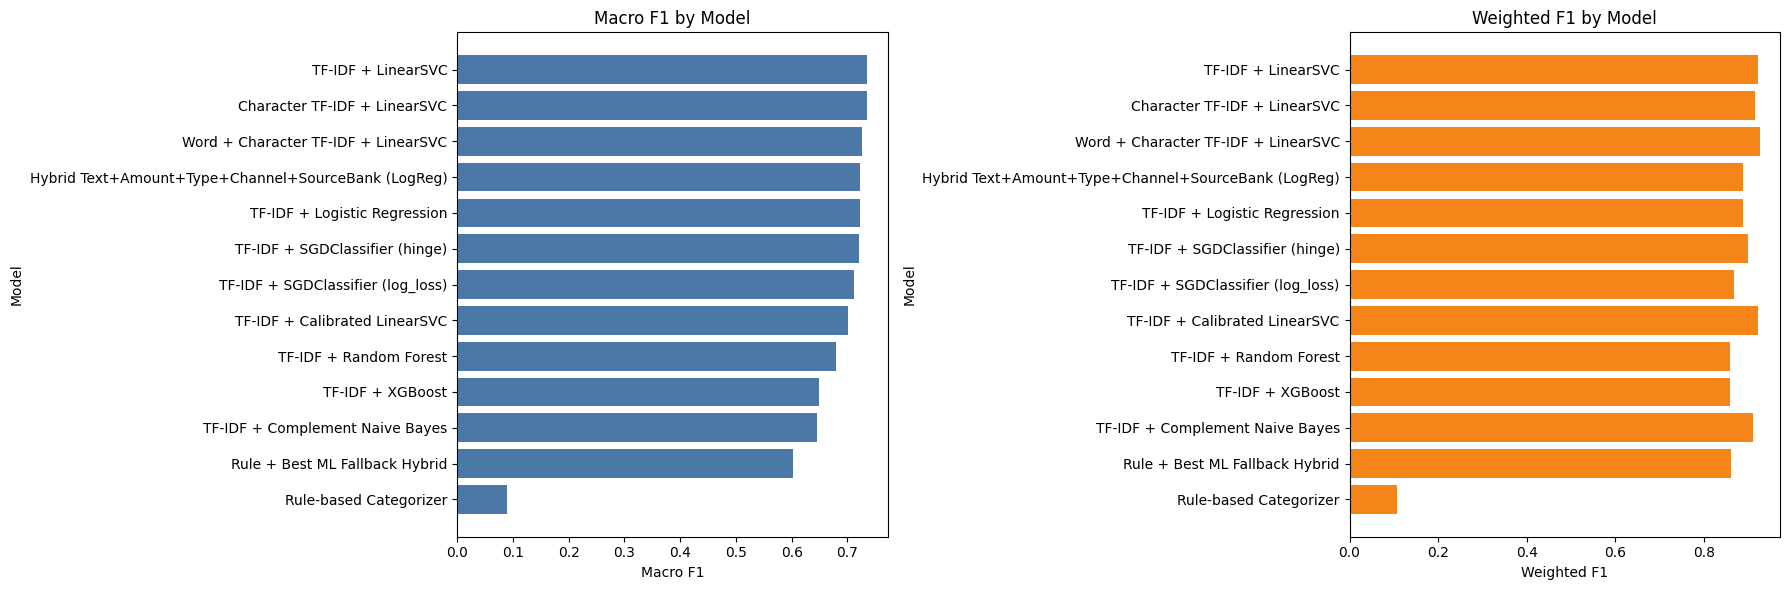

In [21]:

# Plot comparison (matplotlib only)

plot_df = results_df.copy()

fig_height = max(6, 0.45 * len(plot_df))
fig, axes = plt.subplots(1, 2, figsize=(18, fig_height))

axes[0].barh(plot_df["model_name"], plot_df["macro_f1"], color="#4C78A8")
axes[0].invert_yaxis()
axes[0].set_title("Macro F1 by Model")
axes[0].set_xlabel("Macro F1")
axes[0].set_ylabel("Model")

axes[1].barh(plot_df["model_name"], plot_df["weighted_f1"], color="#F58518")
axes[1].invert_yaxis()
axes[1].set_title("Weighted F1 by Model")
axes[1].set_xlabel("Weighted F1")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()


Best model selected for confusion matrix: TF-IDF + LinearSVC
Showing confusion matrix for top 20 most common categories.


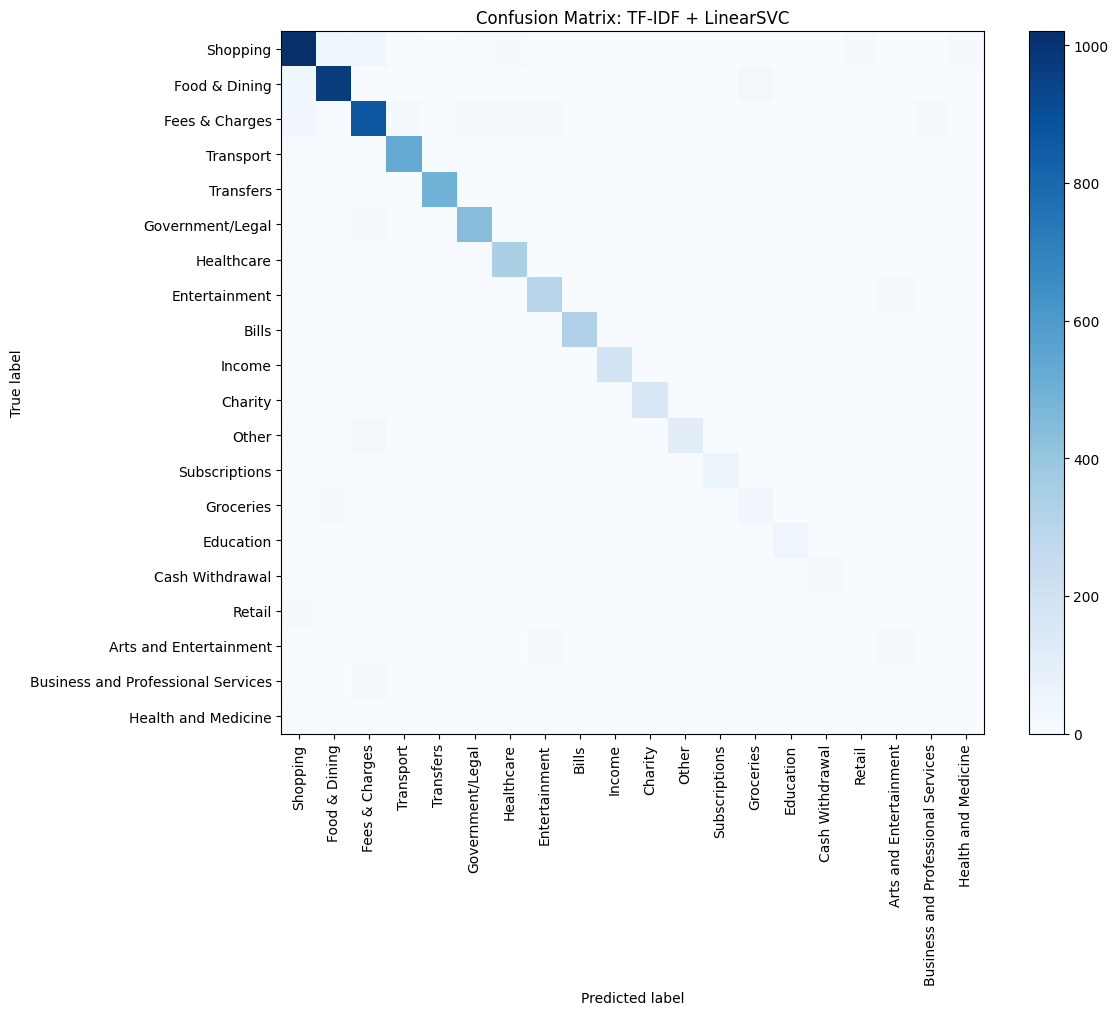

In [22]:

# Confusion matrix for best model by macro F1

best_model_name = results_df.iloc[0]["model_name"]
best_predictions = pd.Series(predictions_store[best_model_name])

print("Best model selected for confusion matrix:", best_model_name)

unique_label_count = y_test.nunique()
if unique_label_count > 20:
    top_labels = y_test.value_counts().head(20).index.tolist()
    mask = y_test.isin(top_labels)
    y_true_cm = y_test[mask]
    y_pred_cm = best_predictions[mask]
    labels_for_cm = top_labels
    print("Showing confusion matrix for top 20 most common categories.")
else:
    y_true_cm = y_test
    y_pred_cm = best_predictions
    labels_for_cm = sorted(pd.unique(pd.concat([y_true_cm, y_pred_cm], ignore_index=True)))

cm = confusion_matrix(y_true_cm, y_pred_cm, labels=labels_for_cm)

fig, ax = plt.subplots(figsize=(max(10, len(labels_for_cm) * 0.6), max(8, len(labels_for_cm) * 0.5)))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(labels_for_cm)),
    yticks=np.arange(len(labels_for_cm)),
    xticklabels=labels_for_cm,
    yticklabels=labels_for_cm,
    ylabel="True label",
    xlabel="Predicted label",
    title=f"Confusion Matrix: {best_model_name}",
)
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
plt.tight_layout()
plt.show()


In [23]:

# Error analysis: show 30 wrong predictions

error_df = X_test.copy()
error_df["true_category"] = y_test.values
error_df["predicted_category"] = best_predictions.values

wrong_df = error_df[error_df["true_category"] != error_df["predicted_category"]].copy()

print(f"Total wrong predictions for {best_model_name}: {len(wrong_df)}")

display(
    wrong_df[
        [
            "description",
            "amount",
            "type",
            "channel",
            "true_category",
            "predicted_category",
        ]
    ].head(30)
)


Total wrong predictions for TF-IDF + LinearSVC: 514


,description,amount,type,channel,true_category,predicted_category
8,"Rite Aid #4567 Purchase on 03/22/25 AZ, Locati...",29.95,,,Retail,Shopping
29,GOODWILL DONATION CENTER #7890 ITEMS DONATED –...,0.00,,,Other,Shopping
43,Auditorio Municipal #789 EVENT TICKET 2025-11-...,45.00,,,Fees & Charges,Arts and Entertainment
69,Restaurant Payment - Clifton Hyderabad - REF 5...,19152.00,,,Food & Dining,Groceries
117,El Jarocho Carnicerias #45678 PURCHASE 12/03/2...,32.99,,,Shopping,Food & Dining
126,ALON DESIGN AND REMODELING #789 PURCHASE FOR H...,1245.00,,,Shopping,Fees & Charges
151,Arby's - Closed #789 PURCHASE IN STORE PHOENIX AZ,14.95,,,Food & Dining,Shopping
165,"Toll Brothers #8765 PROPERTY PURCHASE AZ, USA",195000.00,,,Business and Professional Services,Transport
172,Teavana #7892 PURCHASE FOR TEA BLANKETS & TREA...,45.95,,,Shopping,Food & Dining
189,CENTURY A/C SUPPLY #7891 ORDER 456 HVAC SYSTEM...,1299.00,,,Shopping,Fees & Charges


In [24]:

# Test custom examples

custom_examples = [
    "VISA Local POS Purchase at KFC-MARDAN MARDAN PK",
    "Cash Withdrawal at ATM-B-17 ISLAMABAD PK",
    "ATM Switch Charges",
    "Raast IBFT to MUHAMMAD BILAL IBAN ****9866",
    "UBL Raast IBFT from MUHAMMAD ZUBAIR IBAN ****5886",
    "VISA Local POS Purchase at CHEEZIOUS ISLAMABAD PK",
    "Mobile App Askari Bank Ltd IQRA UNIVERSITY COLLECTION A/C",
    "VISA Local POS Purchase at SHELL ISLAMABAD PK",
    "APPLE.COM/BILL ITUNES.COM IE",
    "VISA Local POS Purchase at SHOPIX CASH AND CARRY Islamabad PK",
    "Raast IBFT to ELITE TRANSPORT SYSTEM IBAN ****3896",
]

examples_df = pd.DataFrame(
    {
        "description": custom_examples,
        "merchant": [""] * len(custom_examples),
        "amount": [0.0] * len(custom_examples),
        "type": [""] * len(custom_examples),
        "channel": [""] * len(custom_examples),
        "source_bank": ["unknown"] * len(custom_examples),
    }
)

examples_df["source_bank"] = examples_df.apply(detect_source_bank_if_missing, axis=1)
examples_df["text_features"] = examples_df.apply(build_text_features, axis=1)

# Use best ML fallback model from hybrid section
best_ml_model_obj = trained_models.get(best_ml_model_name)
best_ml_preds = predict_with_model(best_ml_model_name, best_ml_model_obj, examples_df)

rule_preds = []
rule_strengths = []
hybrid_preds_examples = []
for _, row in examples_df.iterrows():
    rule_category, strength = rule_based_categorizer(
        row.get("description", ""),
        row.get("merchant", ""),
        row.get("channel", ""),
    )
    final_rule_pred = rule_category if rule_category else "Other"
    rule_preds.append(final_rule_pred)
    rule_strengths.append(strength)

    if rule_category and strength == "strong":
        hybrid_preds_examples.append(rule_category)
    else:
        row_df = pd.DataFrame([row])
        hybrid_preds_examples.append(predict_with_model(best_ml_model_name, best_ml_model_obj, row_df)[0])

prediction_table = pd.DataFrame(
    {
        "description": custom_examples,
        "best_ml_model": best_ml_model_name,
        "best_ml_prediction": best_ml_preds,
        "rule_prediction": rule_preds,
        "rule_strength": rule_strengths,
        "hybrid_prediction": hybrid_preds_examples,
    }
)

display(prediction_table)


,description,best_ml_model,best_ml_prediction,rule_prediction,rule_strength,hybrid_prediction
0,VISA Local POS Purchase at KFC-MARDAN MARDAN PK,TF-IDF + LinearSVC,Food & Dining,Food & Dining,strong,Food & Dining
1,Cash Withdrawal at ATM-B-17 ISLAMABAD PK,TF-IDF + LinearSVC,Cash Withdrawal,Cash Withdrawal,strong,Cash Withdrawal
2,ATM Switch Charges,TF-IDF + LinearSVC,Fees & Charges,Cash Withdrawal,strong,Cash Withdrawal
3,Raast IBFT to MUHAMMAD BILAL IBAN ****9866,TF-IDF + LinearSVC,Transfers,Transfers,strong,Transfers
4,UBL Raast IBFT from MUHAMMAD ZUBAIR IBAN ****5886,TF-IDF + LinearSVC,Transfers,Income,strong,Income
5,VISA Local POS Purchase at CHEEZIOUS ISLAMABAD PK,TF-IDF + LinearSVC,Food & Dining,Food & Dining,strong,Food & Dining
6,Mobile App Askari Bank Ltd IQRA UNIVERSITY COL...,TF-IDF + LinearSVC,Education,Education,strong,Education
7,VISA Local POS Purchase at SHELL ISLAMABAD PK,TF-IDF + LinearSVC,Transport,Transport,strong,Transport
8,APPLE.COM/BILL ITUNES.COM IE,TF-IDF + LinearSVC,Bills,Subscriptions,strong,Subscriptions
9,VISA Local POS Purchase at SHOPIX CASH AND CAR...,TF-IDF + LinearSVC,Groceries,Shopping,strong,Shopping


In [25]:

# Save experimental best model and results

MODELS_DIR.mkdir(parents=True, exist_ok=True)
results_output_path = MODELS_DIR / "model_comparison_results.csv"
experimental_model_path = MODELS_DIR / "experimental_best_categorizer.pkl"
production_model_path = MODELS_DIR / "categorizer.pkl"

production_exists = production_model_path.exists()
production_mtime_before = production_model_path.stat().st_mtime if production_exists else None

results_df.to_csv(results_output_path, index=False)

non_serializable_or_non_ml = {"Rule-based Categorizer", "Rule + Best ML Fallback Hybrid"}
ml_only_df = results_df[~results_df["model_name"].isin(non_serializable_or_non_ml)].copy()
if ml_only_df.empty:
    raise RuntimeError("No serializable ML model available to save.")

best_ml_for_saving_name = ml_only_df.iloc[0]["model_name"]
best_ml_for_saving_obj = trained_models[best_ml_for_saving_name]
best_overall_name = results_df.iloc[0]["model_name"]

experiment_payload = {
    "saved_at_utc": datetime.utcnow().isoformat() + "Z",
    "random_state": RANDOM_STATE,
    "best_overall_model_name": best_overall_name,
    "best_ml_model_name": best_ml_for_saving_name,
    "best_ml_model": best_ml_for_saving_obj,
    "model_input_kind": model_input_kind,
    "results": results_df.to_dict(orient="records"),
}

joblib.dump(experiment_payload, experimental_model_path)

production_unchanged = True
if production_exists:
    production_unchanged = production_model_path.stat().st_mtime == production_mtime_before

print("Saved comparison results:", results_output_path)
print("Saved experimental model:", experimental_model_path)
print("Production model path:", production_model_path)
print("Production model untouched in this cell:", production_unchanged)


Saved comparison results: D:\fyp\ml\models\model_comparison_results.csv
Saved experimental model: D:\fyp\ml\models\experimental_best_categorizer.pkl
Production model path: D:\fyp\ml\models\categorizer.pkl
Production model untouched in this cell: True


In [26]:

# Final recommendation (auto-generated markdown)

from IPython.display import display, Markdown

best_row = results_df.iloc[0]
best_model_name_final = best_row["model_name"]
best_macro_f1 = float(best_row["macro_f1"])
best_weighted_f1 = float(best_row["weighted_f1"])

hybrid_row = results_df[results_df["model_name"] == "Rule + Best ML Fallback Hybrid"]
best_ml_row_now = results_df[~results_df["model_name"].isin(["Rule-based Categorizer", "Rule + Best ML Fallback Hybrid"])].iloc[0]

hybrid_improved = False
hybrid_vs_best_ml_msg = "Hybrid result not available."
if not hybrid_row.empty:
    hybrid_macro = float(hybrid_row.iloc[0]["macro_f1"])
    best_ml_macro = float(best_ml_row_now["macro_f1"])
    hybrid_improved = hybrid_macro > best_ml_macro
    hybrid_vs_best_ml_msg = (
        f"Hybrid macro_f1={hybrid_macro:.4f} vs best pure ML macro_f1={best_ml_macro:.4f}"
    )

recommended_next_step = (
    "If this notebook winner is stable across new labeled bank statements, "
    "promote the same feature recipe into the project training pipeline and retrain on merged historical + newly labeled data."
)

final_md = "\n".join([
    "## Final Recommendation",
    "",
    f"- **Best model name:** `{best_model_name_final}`",
    f"- **Best macro F1:** `{best_macro_f1:.4f}`",
    f"- **Best weighted F1:** `{best_weighted_f1:.4f}`",
    f"- **Did hybrid improve over best pure ML?** `{hybrid_improved}`",
    f"- **Hybrid comparison:** {hybrid_vs_best_ml_msg}",
    f"- **Recommended next step:** {recommended_next_step}",
    "",
    "For the current TF-IDF/LinearSVC style model, we do not fine-tune like BERT. We retrain using old datasets plus newly labeled bank statement data.",
])
display(Markdown(final_md))


## Final Recommendation

- **Best model name:** `TF-IDF + LinearSVC`
- **Best macro F1:** `0.7351`
- **Best weighted F1:** `0.9211`
- **Did hybrid improve over best pure ML?** `False`
- **Hybrid comparison:** Hybrid macro_f1=0.6029 vs best pure ML macro_f1=0.7351
- **Recommended next step:** If this notebook winner is stable across new labeled bank statements, promote the same feature recipe into the project training pipeline and retrain on merged historical + newly labeled data.

For the current TF-IDF/LinearSVC style model, we do not fine-tune like BERT. We retrain using old datasets plus newly labeled bank statement data.